### Kwateng Kofi Owusu Clement
### Using  the NYHousing file  and Linear Regression 
### To find the Price of  a 5 bedrooom 5 bathrooms and a property feet of 350



### Listing the Target and Three Relevant feature 
### Target -Price
### Features - Number of Room, Bathroom and PROPERTYSQF


In [7]:
#Importing packages
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LinearRegression 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
#Loading the csv file  
df= pd.read_csv("NYHousing.csv")


In [1]:
### Understanding the data

#displaying the first five rows 
df.head()

In [86]:
#Narrowing our data 
# ==========================================
# 2) Narrow Down Columns (Features, Target, & Location)
# ==========================================
df_narrow = df[['PRICE', 'BEDS', 'BATH', 'PROPERTYSQFT', 'LOCALITY']].copy()

In [87]:
# ==========================================
# 3) Rename PROPERTYSQFT to PSF
# ==========================================
df_narrow = df_narrow.rename(columns={"PROPERTYSQFT": "PSF"})

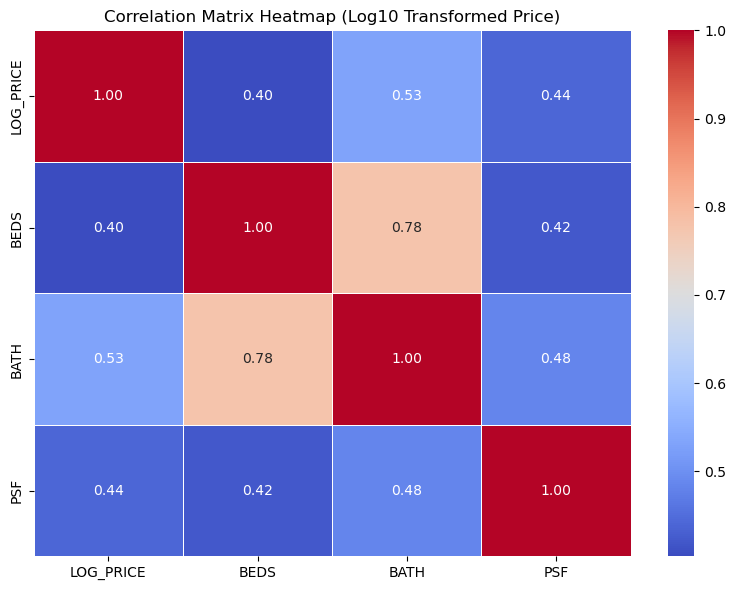

In [88]:
# Generating a heatmap to inspect baseline correlations before log transformation
#corr_matrix = df_narrow[['PRICE', 'BEDS', 'BATH', 'PSF']].corr()
#sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
#plt.title("Correlation Matrix Heatmap")
#plt.show()
df_heatmap = df_narrow[['PRICE', 'BEDS', 'BATH', 'PSF']].copy()

# 2. Apply the log10 transformation to the target price
df_heatmap['LOG_PRICE'] = np.log10(df_heatmap['PRICE'])

# 3. Drop the old raw PRICE column so it doesn't clutter the matrix
df_heatmap = df_heatmap.drop(columns=['PRICE'])

# 4. Generate the correlation matrix using the log-transformed price
corr_matrix = df_heatmap[['LOG_PRICE', 'BEDS', 'BATH', 'PSF']].corr()

# 5. Render the beautifully unmasked heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix Heatmap (Log10 Transformed Price)")
plt.tight_layout()
plt.show()


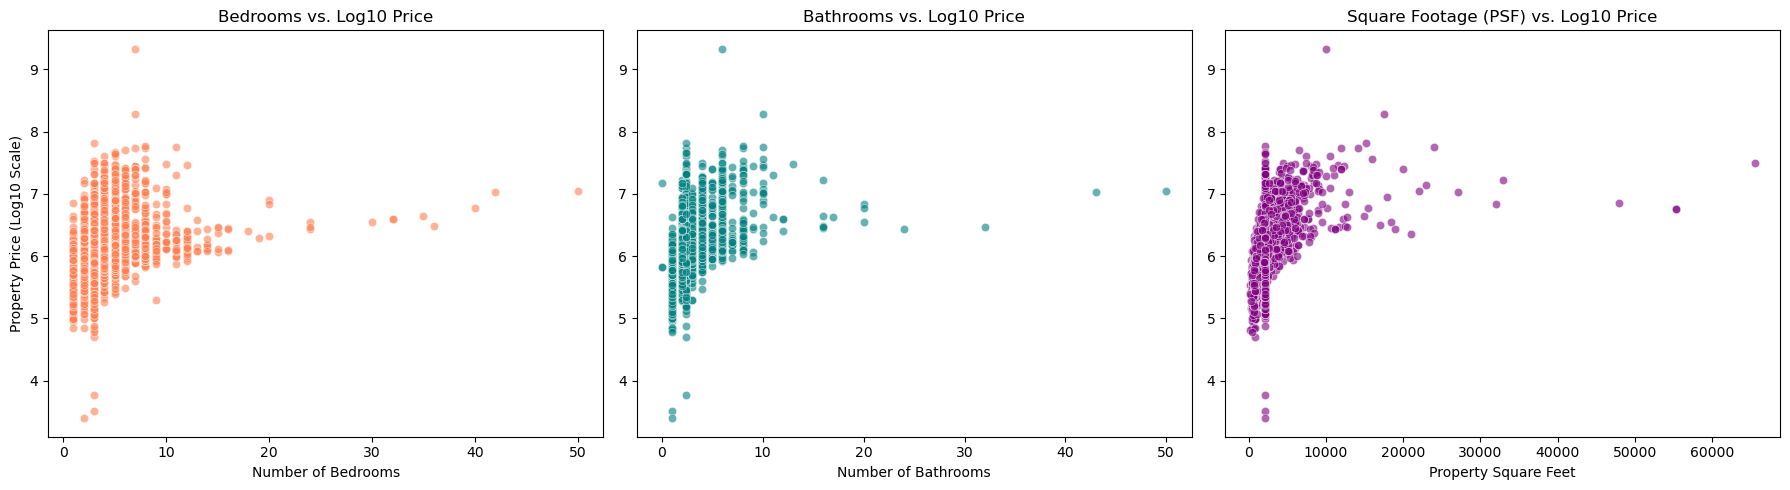

In [89]:
# 1. Create a copy and apply your log10 transformation to Price
df_scatter = df_narrow[['PRICE', 'BEDS', 'BATH', 'PSF']].copy()
df_scatter['LOG_PRICE'] = np.log10(df_scatter['PRICE'])

# 2. Set up a side-by-side plotting grid (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot A: Bedrooms vs Log Price
sns.scatterplot(data=df_scatter, x='BEDS', y='LOG_PRICE', ax=axes[0], alpha=0.6, color='coral')
axes[0].set_title('Bedrooms vs. Log10 Price')
axes[0].set_xlabel('Number of Bedrooms')
axes[0].set_ylabel('Property Price (Log10 Scale)')

# Plot B: Bathrooms vs Log Price
sns.scatterplot(data=df_scatter, x='BATH', y='LOG_PRICE', ax=axes[1], alpha=0.6, color='teal')
axes[1].set_title('Bathrooms vs. Log10 Price')
axes[1].set_xlabel('Number of Bathrooms')
axes[1].set_ylabel('') # Clear y-label to avoid crowding

# Plot C: Square Footage (PSF) vs Log Price
sns.scatterplot(data=df_scatter, x='PSF', y='LOG_PRICE', ax=axes[2], alpha=0.6, color='purple')
axes[2].set_title('Square Footage (PSF) vs. Log10 Price')
axes[2].set_xlabel('Property Square Feet')
axes[2].set_ylabel('')

# 3. Clean layout and display
plt.tight_layout()
plt.show()

In [90]:
# ==========================================
# 5) Preprocessing (Outliers via IQR Capping)
# ==========================================
numerical_features = ['BEDS', 'BATH', 'PSF']

for col in numerical_features:
    Q1 = df_narrow[col].quantile(0.25) 
    Q3 = df_narrow[col].quantile(0.75) 
    IQR = Q3 - Q1 
    Lower_bound = Q1 - (IQR * 1.5) 
    Upper_bound = Q3 + (IQR * 1.5) 
    
    # Sequential capping
    df_narrow[col] = np.where(df_narrow[col] < Lower_bound, Lower_bound, df_narrow[col]) 
    df_narrow[col] = np.where(df_narrow[col] > Upper_bound, Upper_bound, df_narrow[col])

In [91]:
# ==========================================
# 6) Transformation Using Z-Values
# ==========================================
# Applying your custom (+1 shifted) standardization to the numerical features
#for col in numerical_features:
 #   col_mean = df_narrow[col].mean()
  #  col_std = df_narrow[col].std()
  #  df_narrow[f"z_{col}"] = ((df_narrow[col] - col_mean) / col_std) + 1

stats = {}
for col in numerical_features:
    col_mean = df_narrow[col].mean()
    col_std = df_narrow[col].std()
    stats[col] = {'mean': col_mean, 'std': col_std}
    df_narrow[f"z_{col}"] = ((df_narrow[col] - col_mean) / col_std) + 1    

In [92]:
df_narrow['LOG_PRICE'] = np.log10(df_narrow['PRICE'])

In [93]:
# ==========================================
# 8) Identify the Target and Features
# ==========================================
# X contains multiple z-scaled features and our encoded location column
X = df_narrow[["z_BEDS", "z_BATH", "z_PSF"]] 
y = df_narrow["LOG_PRICE"]

In [94]:
# ==========================================
# 9) Split Train and Test Sets
# ==========================================
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [95]:
# ==========================================
# 10) Train the Model
# ==========================================
model = LinearRegression() 
model.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [96]:
# ==========================================
# 8) NEW & IMPROVED: Professional Scaling
# ==========================================
scaler = StandardScaler()

# Fit only on training features, then transform both sets
# (Note: We usually only scale the continuous features, but scaling the encoded location is perfectly fine too!)
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [109]:
print("==== Model Structural Estimators (Z-Features & Log-Target) ====")
print(f"Log-Baseline Intercept: {model.intercept_:.4f}")
for feature, coef in zip(X.columns, model.coef_):
    print(f"Feature: {feature:16} | Weight/Coefficient: {coef:.4f}")
y_pred = model.predict(x_test_scaled)
y_pred2 = model.predict(x_test)


#print("==== Model Performance with StandardScaler ====")
#print(f"R-squared Score (R2): {r2_score(y_test, y_pred2):.4f}")

==== Model Structural Estimators (Z-Features & Log-Target) ====
Log-Baseline Intercept: 5.6353
Feature: z_BEDS           | Weight/Coefficient: -0.0194
Feature: z_BATH           | Weight/Coefficient: 0.2236
Feature: z_PSF            | Weight/Coefficient: 0.1270


C:\Users\USER\AppData\Local\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [98]:
# 5) Custom Property Prediction (5 Beds, 5 Baths, 350 Sq Ft)
# ==========================================
new_beds, new_bath, new_psf = 5, 5, 350

# Transform inputs to match training Z-scores
z_beds_val = ((new_beds - stats['BEDS']['mean']) / stats['BEDS']['std']) + 1
z_bath_val = ((new_bath - stats['BATH']['mean']) / stats['BATH']['std']) + 1
z_psf_val  = ((new_psf - stats['PSF']['mean']) / stats['PSF']['std']) + 1

new_property = pd.DataFrame([[z_beds_val, z_bath_val, z_psf_val]], columns=X.columns)

# CRITICAL: The model outputs a LOG price. We must use 10** to convert it back to normal Dollars!
predicted_log_price = model.predict(new_property)[0]
final_dollar_price = 10 ** predicted_log_price

print("\n" + "="*50)
print(f"  Predicted Log10 Value:  {predicted_log_price:.4f}")
print(f"  FINAL REAL ESTATE PRICE: ${final_dollar_price:,.2f}")
print("="*50)
# Let's say a new house hits the market: 5 Beds, 5 Baths, 350 Sq Ft, Location Code 1 (Brooklyn)
#new_property = pd.DataFrame([[5,  350, 1]], columns=X.columns)

# Scale using the same scaler fitted on training data
#new_property_scaled = scaler.transform(new_property)

# Predict
#predicted_price = model.predict(new_property_scaled)[0]
#predicted_price2 = model.predict(new_property)[0]

#print()
#print("=" * 45)
#print(f"  Predicted Price for New Property: ${predicted_price2:,.2f}")
#print(f"  Predicted Price for New Property: ${predicted_price:,.2f}")
#print("=" * 45)


  Predicted Log10 Value:  6.1651
  FINAL REAL ESTATE PRICE: $1,462,581.86


In [105]:
# ---- Evaluation Metric 1: RMSE ----
mse  = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)

print("Evaluation Test 1: Root Mean Squared Error (RMSE)")
print("-" * 50)
print(f"  MSE  (Mean Squared Error)  : ${mse:>20,.2f}")
print(f"  RMSE (Root MSE)            : ${rmse:>20,.2f}")
print()
print("  Interpretation:")
print(f"  On average, our model's predictions are off by")
print(f"  approximately ${rmse:,.2f} from the actual price.")

Evaluation Test 1: Root Mean Squared Error (RMSE)
--------------------------------------------------
  MSE  (Mean Squared Error)  : $                0.12
  RMSE (Root MSE)            : $                0.34

  Interpretation:
  On average, our model's predictions are off by
  approximately $0.34 from the actual price.


In [111]:
# ---- Evaluation Metric 2: R² Score ----
r2 = r2_score(y_test, y_pred2)

print("Evaluation Test 2: R² Score (Coefficient of Determination)")
print("-" * 55)
print(f"  R² Score: {r2:.4f}  ({r2*100:.2f}%)")
print()
print("  Interpretation:")
print(f"  The model explains {r2*100:.2f}% of the variance in PRICE.")
if r2 >= 0.7:
    print("Strong fit — the model predicts well.")
elif r2 >= 0.4:
    print("Moderate fit — predictions are reasonable but not highly accurate.")
else:
    print("Weak fit — the model explains limited variance; more features needed.")

Evaluation Test 2: R² Score (Coefficient of Determination)
-------------------------------------------------------
  R² Score: 0.4645  (46.45%)

  Interpretation:
  The model explains 46.45% of the variance in PRICE.
Moderate fit — predictions are reasonable but not highly accurate.


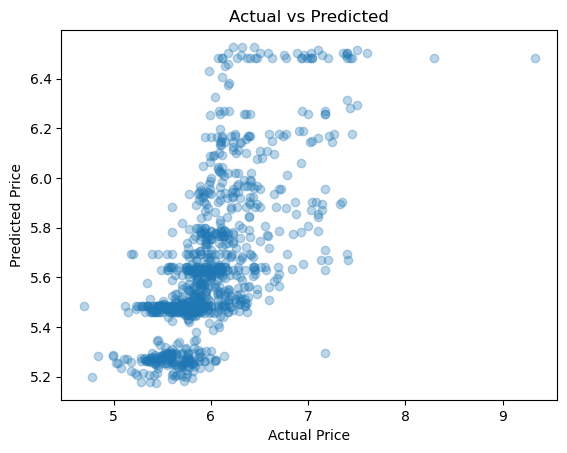

In [112]:
# visualise actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.3)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.show()